In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LinearRegression,Ridge,ElasticNet,Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import time
from scipy.stats import loguniform, uniform
from sklearn.model_selection import learning_curve

In [2]:
df=pd.read_csv("C:/Users/DHARSHINI/Downloads/sem5/machine-learning/expermient-3/archive (1)/train.csv")
df.columns

Index(['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)',
       'Income Stability', 'Profession', 'Type of Employment', 'Location',
       'Loan Amount Request (USD)', 'Current Loan Expenses (USD)',
       'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Has Active Credit Card', 'Property ID',
       'Property Age', 'Property Type', 'Property Location', 'Co-Applicant',
       'Property Price', 'Loan Sanction Amount (USD)'],
      dtype='object')

In [3]:
def missing_values_handling(df):

    df=df.replace(-999,np.nan)
    df=df.drop("Name",axis=1)
    df=df.drop("Customer ID",axis=1)

    df.loc[:,"Loan Sanction Amount (USD)"]=df["Loan Sanction Amount (USD)"].dropna()
    df.loc[:,"Income (USD)"]=df["Income (USD)"].fillna(df["Income (USD)"].median())
    df.loc[:,"Current Loan Expenses (USD)"]=df["Current Loan Expenses (USD)"].fillna(df["Current Loan Expenses (USD)"].median())
    df.loc[:,"Property Age"]=df["Property Age"].fillna(df["Property Age"].median())
    df.loc[:,"Property Price"]=df["Property Price"].fillna(df["Property Price"].median())
    df = df.dropna(subset=["Loan Sanction Amount (USD)"])

    df.loc[:,"Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
    df.loc[:,"Dependents"]=df["Dependents"].fillna(df["Dependents"].median())
    df.loc[:,"Credit Score"]=df["Credit Score"].fillna(df["Credit Score"].median())
    df.loc[:,"Property Location"]=df["Property Location"].fillna(df["Property Location"].mode()[0])
    df.loc[:,"Type of Employment"]=df["Type of Employment"].fillna(df["Type of Employment"].mode()[0])
    df.loc[:,"Income Stability"]=df["Income Stability"].fillna(df["Income Stability"].mode()[0])
    df.loc[:,"Property Location"]=df["Property Location"].fillna(df["Property Location"].mode()[0])
    df.loc[:,"Has Active Credit Card"]=df["Has Active Credit Card"].fillna(df["Has Active Credit Card"].mode())
    df.loc[:,"Co-Applicant"]=df["Co-Applicant"].fillna(df["Co-Applicant"].median())
    df.loc[:,"Profession"]=df["Profession"].fillna(df["Profession"].mode())

    print("\n\nNULL VALUES \n\n",df.isnull().sum())

    df = df.dropna(subset=['Loan Sanction Amount (USD)'])
    return df
    

In [4]:
def outliers(df):
    print("OUTLIERS VISUALS")
    cate=df.select_dtypes(include="number").columns
    for col in cate:
        plt.figure(figsize=(5,5))
        try:
            plt.boxplot(df[col].dropna())
            plt.title(col)
            plt.show()
        except Exception as e:
            print(f"Error in {col}: {e}")
    return df

## Encoding Categorical Variables 

In [5]:
def encoding(df):

    encoding_col=["Gender","Has Active Credit Card","Has Active Credit Card","Property Location","Profession","Location","Type of Employment","Income Stability","Expense Type 1","Expense Type 2"]
    for col in encoding_col:
        print("\nUNIQUE VALEUS  ",col, " : ",df[col].unique())
        
    binary_clasified=["Gender","Expense Type 2","Expense Type 1"]
    df["Gender"]=df["Gender"].map({
            "M":0,
            "F":1
    })

    df["Expense Type 1"]=df["Expense Type 1"].map({
            "Y":0,
            "N":1
    })
    df["Expense Type 2"]=df["Expense Type 2"].map({
            "Y":0,
            "N":1
    })

    nominal_cols=["Property Location","Profession","Location","Type of Employment","Has Active Credit Card"]
    df=pd.get_dummies(df,columns=nominal_cols,drop_first=True,dtype=int)

    encoder=OrdinalEncoder(
        categories=[["Low","High"]]
    )
    df["Income Stability"]=encoder.fit_transform(df[["Income Stability"]])

    print("\n\nCOLUMNS \n\n",df.columns)
    print(df.head())

    return df

## STANDERDIZING 

In [6]:

def standarddize(df):
    numerical_cols = [
    "Age",
    "Income (USD)",
    "Current Loan Expenses (USD)",
    "Dependents",
    "Credit Score",
    "Property Age",
    "Property Price"
    ]

    scaler=StandardScaler()

    x=df.drop('Loan Sanction Amount (USD)' , axis=1)
    y=df["Loan Sanction Amount (USD)"]
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

    x_train[numerical_cols]=scaler.fit_transform(x_train[numerical_cols])
    x_test[numerical_cols]=scaler.transform(x_test[numerical_cols])

    print(x)
    return x_train, x_test, y_train, y_test



NULL VALUES 

 Gender                            0
Age                               0
Income (USD)                      0
Income Stability                  0
Profession                        0
Type of Employment                0
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)       0
Expense Type 1                    0
Expense Type 2                    0
Dependents                        0
Credit Score                      0
No. of Defaults                   0
Has Active Credit Card         1520
Property ID                       0
Property Age                      0
Property Type                     0
Property Location                 0
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)        0
dtype: int64
OUTLIERS VISUALS


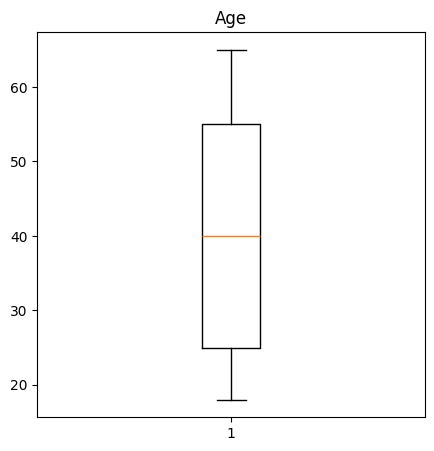

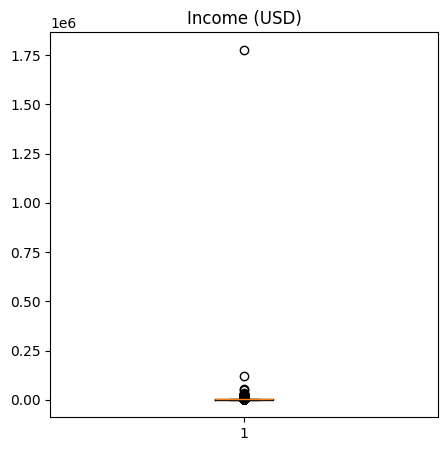

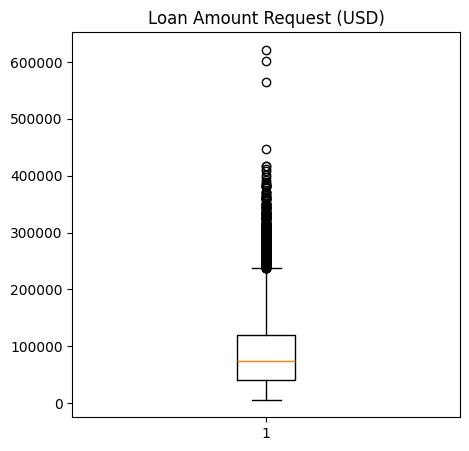

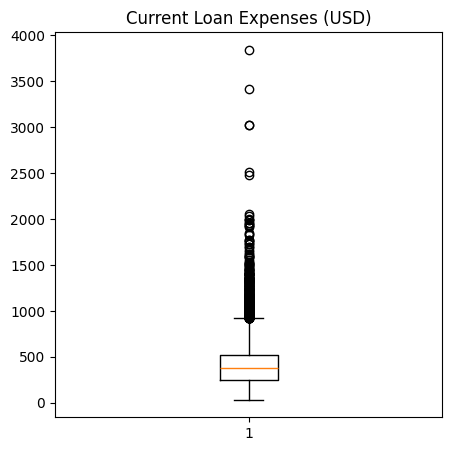

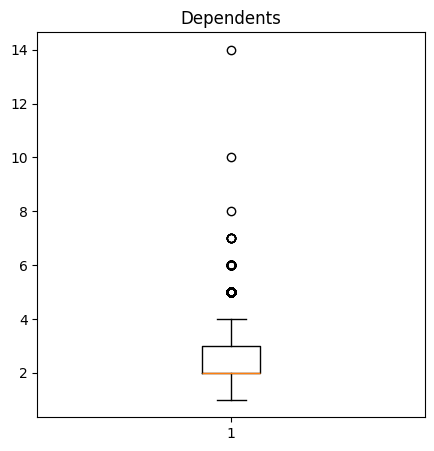

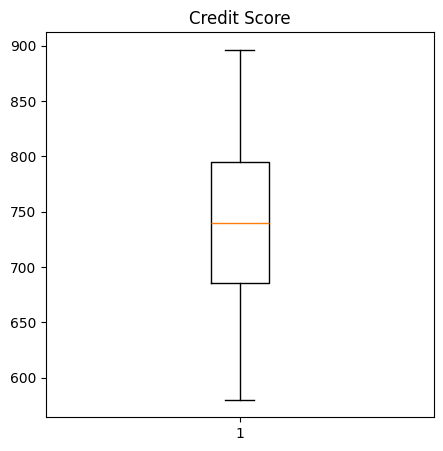

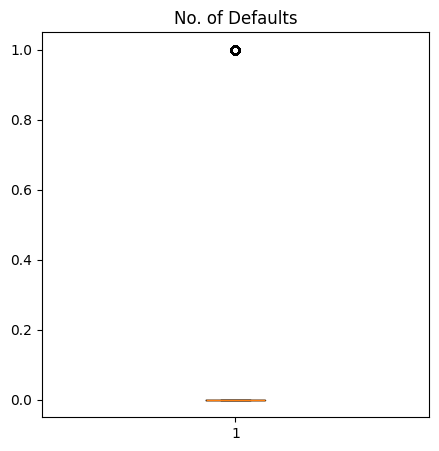

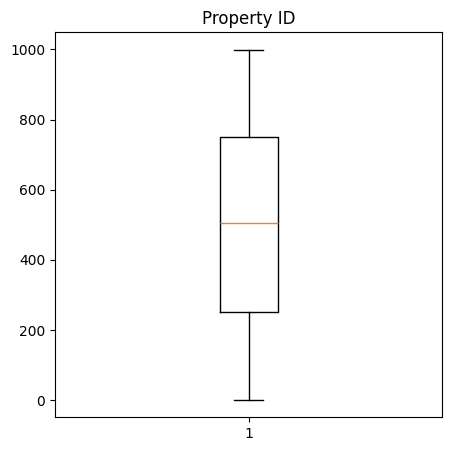

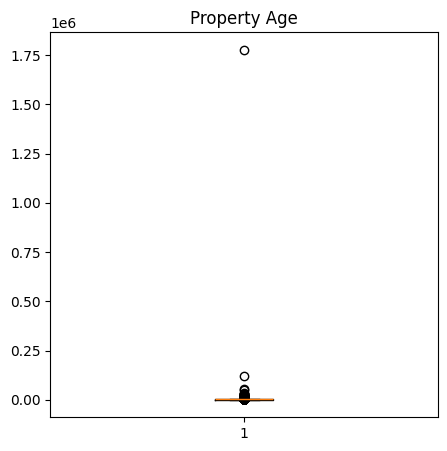

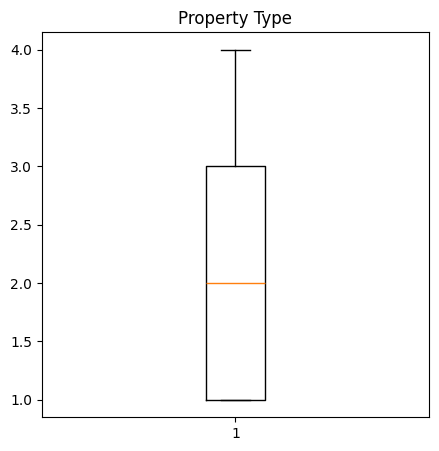

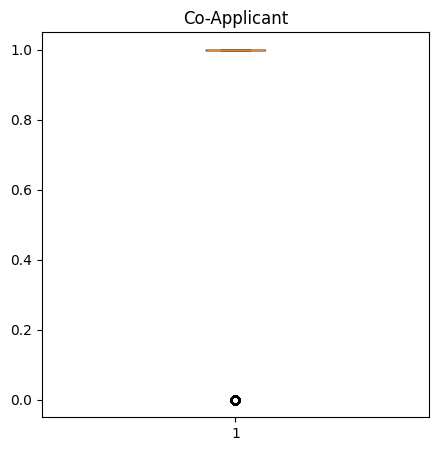

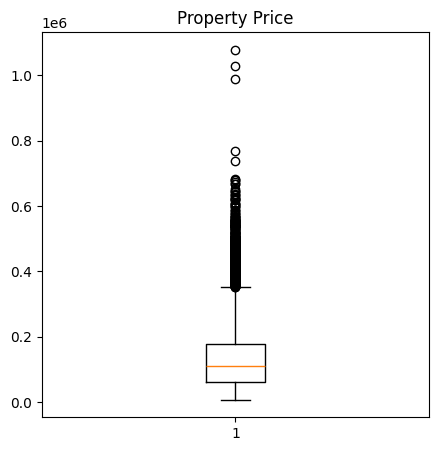

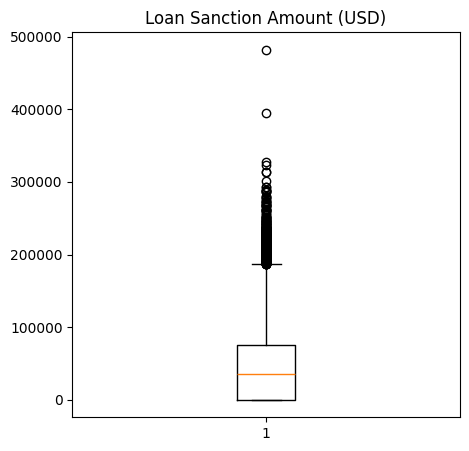


UNIQUE VALEUS   Gender  :  ['F' 'M']

UNIQUE VALEUS   Has Active Credit Card  :  ['Active' 'Unpossessed' 'Inactive' nan]

UNIQUE VALEUS   Has Active Credit Card  :  ['Active' 'Unpossessed' 'Inactive' nan]

UNIQUE VALEUS   Property Location  :  ['Rural' 'Urban' 'Semi-Urban']

UNIQUE VALEUS   Profession  :  ['Working' 'Pensioner' 'State servant' 'Commercial associate' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave']

UNIQUE VALEUS   Location  :  ['Semi-Urban' 'Rural' 'Urban']

UNIQUE VALEUS   Type of Employment  :  ['Sales staff' 'Laborers' 'High skill tech staff' 'Secretaries' 'Managers'
 'Cooking staff' 'Core staff' 'Drivers' 'Realty agents' 'Security staff'
 'Accountants' 'Private service staff' 'Waiters/barmen staff'
 'Medicine staff' 'Cleaning staff' 'Low-skill Laborers' 'HR staff'
 'IT staff']

UNIQUE VALEUS   Income Stability  :  ['Low' 'High']

UNIQUE VALEUS   Expense Type 1  :  ['N' 'Y']

UNIQUE VALEUS   Expense Type 2  :  ['N' 'Y']


COLUMNS 

 Index(['Gender', 'Age', 

In [7]:
df=missing_values_handling(df)
df=outliers(df)
df=encoding(df)

In [8]:
x_train, x_test, y_train, y_test=standarddize(df)


       Gender  Age  Income (USD)  Income Stability  Loan Amount Request (USD)  \
0           1   56      1933.050               0.0                   72809.58   
1           0   32      4952.910               0.0                   46837.47   
2           1   65       988.190               1.0                   45593.04   
3           1   65      2222.435               1.0                   80057.92   
4           1   31      2614.770               0.0                  113858.89   
...       ...  ...           ...               ...                        ...   
29995       0   38      4969.410               0.0                   76657.90   
29996       0   20      1606.880               0.0                   66595.14   
29997       1   49      2222.435               0.0                   81410.08   
29998       0   38      2417.710               0.0                  142524.10   
29999       1   63      3068.240               1.0                  156290.54   

       Current Loan Expense

## LInear regression

In [9]:
def evaluting_model(y_predicted,y_test):
    mse=mean_squared_error(y_test,y_predicted)
    print("\n\nMean squared error : ",mse)
    mae=mean_absolute_error(y_test,y_predicted)
    print("\n\nMean Absolute error : ",mae)
    rmse = np.sqrt(mse)
    print("\n\nRoot Mean squared Error : ",rmse)
    r2 = r2_score(y_test, y_predicted)
    print("\n\nR2 Score : ",r2)

In [10]:
lr_start_time=time.time()
linea_regessionr=LinearRegression()
linea_regessionr.fit(x_train,y_train)
lr_train_time=time.time()-lr_start_time
y_predicted=linea_regessionr.predict(x_test)

## Evaluating the Linear Regression

In [11]:
print("Evaluation of Linear regression Model")
print("\n\nTraining Time:",lr_train_time)
evaluting_model(y_predicted,y_test)

Evaluation of Linear regression Model


Training Time: 0.21678924560546875


Mean squared error :  770446862.3488383


Mean Absolute error :  18762.95655853051


Root Mean squared Error :  27756.92458376537


R2 Score :  0.6574771648508133


## Actual vs Predicted Plot 

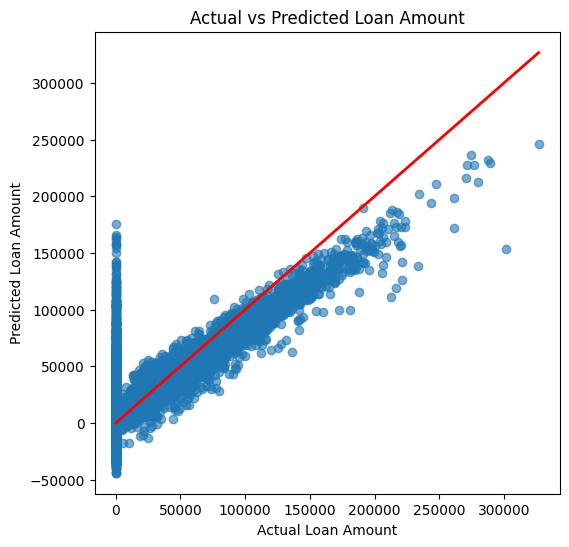

In [14]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_predicted, alpha=0.6)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Amount")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.show()

In [18]:
(df[['Loan Sanction Amount (USD)']]==0).sum()

Loan Sanction Amount (USD)    7865
dtype: int64

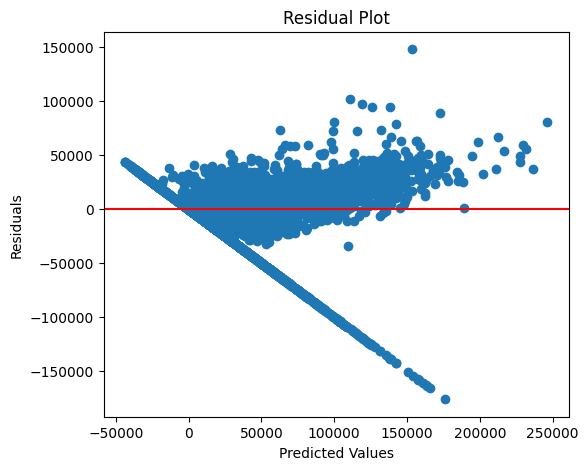

In [47]:
residuals = y_test - y_predicted

plt.figure(figsize=(6,5))

plt.scatter(y_predicted, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Ridge Regression

In [48]:
rl_start_time=time.time()
ridge=Ridge(alpha=100)
ridge.fit(x_train,y_train)
rl_train_time=time.time()-rl_start_time
ridge_prediced=ridge.predict(x_test)

## Evaluation of Ridge Model

In [49]:
print("Evaluation of ridge regression Model")
print("\n\nTraining Time:",rl_train_time)
evaluting_model(ridge_prediced,y_test)

Evaluation of ridge regression Model


Training Time: 0.03868889808654785


Mean squared error :  769895996.0526488


Mean Absolute error :  18747.27311028289


Root Mean squared Error :  27746.99976668917


R2 Score :  0.6577220672506799


## Lasso regression

In [50]:
ls_start_time=time.time()
lasso=Lasso(alpha=100)
lasso.fit(x_train,y_train)
ls_train_time=time.time()-ls_start_time
lasso_predict=lasso.predict(x_test)

## Evaluation Lasso Model 

In [51]:
print("Evaluation of ridge regression Model")
print("\n\nTraining Time : ",ls_train_time)
evaluting_model(lasso_predict,y_test)

Evaluation of ridge regression Model


Training Time :  2.4121625423431396


Mean squared error :  770624774.9015661


Mean Absolute error :  18724.206332121725


Root Mean squared Error :  27760.129230635186


R2 Score :  0.6573980690494712


## Grid search 

In [52]:
param_grid = {
    "alpha":[0.01, 0.1, 1, 10, 100]
}

start_time = time.time()
grid = GridSearchCV(estimator=Ridge(),param_grid=param_grid,scoring="r2",cv=5,n_jobs=-1)

grid.fit(x_train, y_train)

grid_ridge_time=time.time()-start_time
print("\n\nBest Alpha :", grid.best_params_)
print("\n\nBest CV Score :", grid.best_score_)



Best Alpha : {'alpha': 100}


Best CV Score : 0.6469147092240907


In [53]:
best_ridge = grid.best_estimator_

y_pred_best = best_ridge.predict(x_test)

print("\n\nTraining time : ",grid_ridge_time)
print("\n\nR² :", r2_score(y_test, y_pred_best))
print("\n\nRMSE :", np.sqrt(mean_squared_error(y_test, y_pred_best)))



Training time :  3.2256410121917725


R² : 0.6577220672506799


RMSE : 27746.99976668917


## Grid Search Foe lasso regression

In [54]:
lasso_grid = {
    "alpha":[0.001, 0.01, 0.1, 1, 10]
}

lasso_search = GridSearchCV(
    Lasso(max_iter=10),
    lasso_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_search.fit(x_train,y_train)

print(lasso_search.best_params_)
print(lasso_search.best_score_)

{'alpha': 10}
0.6447092313817718


C:\Users\DHARSHINI\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.338e+12, tolerance: 5.496e+09
  model = cd_fast.enet_coordinate_descent(


## Elastic Net model

In [55]:

elastic_time=time.time()
elastic = ElasticNet(
    alpha=100,
    l1_ratio=0.5,
    random_state=42
)

elastic.fit(x_train, y_train)

elstic_time=time.time()-elastic_time
y_pred = elastic.predict(x_test)

## Evaluation of elastic Net model

In [56]:
print("Evaluation of Elasticnet regression Model")
print("\n\ntraining time  : ", elstic_time)
evaluting_model(y_pred,y_test)

Evaluation of Elasticnet regression Model


training time  :  2.640385389328003


Mean squared error :  1033328294.2235498


Mean Absolute error :  23225.899497114835


Root Mean squared Error :  32145.42415684618


R2 Score :  0.5406061673114204


## gridSearchCV for Elastic Regression

In [57]:
elastic_grid = {
    "alpha":[0.01,0.1,1,10],
    "l1_ratio":[0.2,0.5,0.8]
}

elastic_search = GridSearchCV(
    ElasticNet(max_iter=10),
    elastic_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

elastic_search.fit(x_train,y_train)

print(elastic_search.best_params_)
print(elastic_search.best_score_)

{'alpha': 0.1, 'l1_ratio': 0.8}
0.6513562757617877


C:\Users\DHARSHINI\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.616e+12, tolerance: 5.496e+09
  model = cd_fast.enet_coordinate_descent(


## Coeffecient Plot

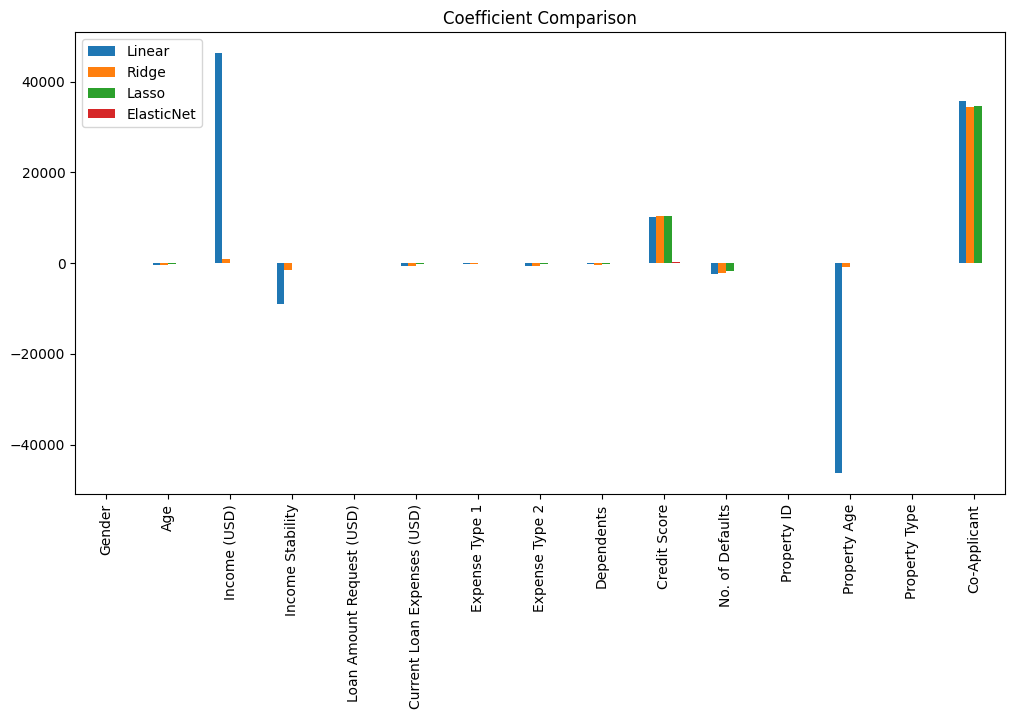

In [58]:
coef_df = pd.DataFrame({
    "Linear": linea_regessionr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
}, index=x_train.columns)

coef_df.head(15).plot(kind="bar", figsize=(12,6))
plt.title("Coefficient Comparison")
plt.show()

## training vs validation

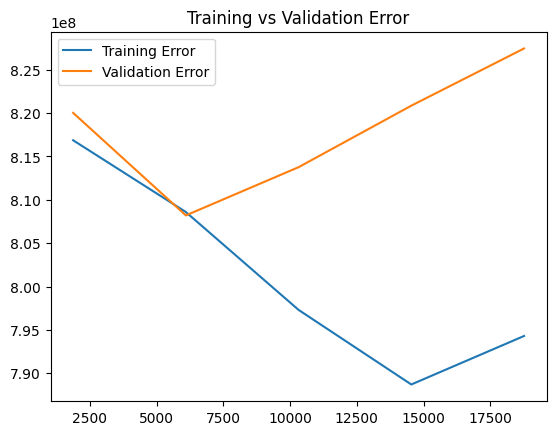

In [59]:


train_sizes, train_scores, val_scores = learning_curve(
    Ridge(alpha=grid.best_params_["alpha"]),
    x_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

train_error = -train_scores.mean(axis=1)
val_error = -val_scores.mean(axis=1)

plt.plot(train_sizes, train_error, label="Training Error")
plt.plot(train_sizes, val_error, label="Validation Error")
plt.legend()
plt.title("Training vs Validation Error")
plt.show()

## Hperparameter tuning summary

In [64]:
tuning_summary = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression", "Elastic Net Regression"],
    "Best Parameters": [
        grid.best_params_,
        lasso_search.best_params_,
        elastic_search.best_params_
    ],
    "Best CV R2": [
        grid.best_score_,
        lasso_search.best_score_,
        elastic_search.best_score_
    ]
})

tuning_summary

,Model,Best Parameters,Best CV R2
0,Ridge Regression,{'alpha': 100},0.646915
1,Lasso Regression,{'alpha': 10},0.644709
2,Elastic Net Regression,"{'alpha': 0.1, 'l1_ratio': 0.8}",0.651356


## Cross validation performance Table 

In [66]:
from sklearn.model_selection import cross_val_score

models = {
    "Linear Regression": linea_regessionr,
    "Ridge Regression": grid,
    "Lasso Regression": lasso_search,
    "Elastic Net Regression": elastic_search
}

cv_results = []

for name, model in models.items():

    r2 = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='r2'
    )

    cv_results.append([
        name,
        np.mean(r2)
    ])

cv_table = pd.DataFrame(
    cv_results,
    columns=["Model", "CV R2 Score"]
)

cv_table

,Model,CV R2 Score
0,Linear Regression,0.642496
1,Ridge Regression,0.646915
2,Lasso Regression,0.659349
3,Elastic Net Regression,0.542912


## Test Set Performance

## Overfitting and Underfitting Analysis

The difference between training and validation errors was analyzed using learning curves. The Linear Regression model showed a moderate gap between training and validation performance, indicating slight variance.

Ridge and Elastic Net regression reduced the gap between training and validation errors by applying regularization. This improved model generalization and reduced overfitting.

Lasso regression removed less important features by shrinking some coefficients to zero, resulting in a simpler model with improved interpretability.

Hyperparameter tuning further improved model performance by selecting the optimal regularization strength and reducing model complexity.

## Bias–Variance Analysis

Linear Regression generally exhibits low bias when the relationship between features and target is approximately linear, but it can suffer from higher variance when irrelevant features are present.

Ridge Regression reduces variance by shrinking coefficient values while retaining all features.

Lasso Regression introduces sparsity by setting some coefficients to zero, which may increase bias slightly but significantly reduces variance.

Elastic Net combines the advantages of Ridge and Lasso by balancing coefficient shrinkage and feature selection, resulting in a better bias–variance trade-off.

## Conclusion

Linear Regression, Ridge Regression, Lasso Regression, and Elastic Net Regression were implemented and evaluated for loan amount prediction.

Hyperparameter tuning improved the performance of regularized models. Ridge Regression reduced coefficient magnitudes, Lasso Regression performed feature selection, and Elastic Net combined both approaches.

Among all models, the model with the highest R² score and lowest prediction error demonstrated the best predictive performance. Regularization improved generalization capability and reduced the risk of overfitting.

The experiment demonstrated the importance of model tuning and regularization in building robust regression models.